In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from time import time
from datetime import datetime
import sys
import math
import tensorflow as tf
import numpy as np
import scipy.optimize
import pandas as pd
import matplotlib.pyplot as plt
from numpy import random
import itertools

In [2]:
# 1. SETUP
DTYPE = 'float32'
tf.keras.backend.set_floatx(DTYPE)
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# Files
# Update these paths to your specific files
url_lf = "Data_LF_SAOS.xlsx"
url_hf = "Data_HF_SAOS.xlsx"
# We need the raw file for the final visualization steps
url_hf_raw = "Data_HF_SAOS_raw.xlsx"

In [3]:
# 2. DATA LOADING (FIXED: Loads ALL sheets, not just sample 0)
print("Loading Data...")

try:
    df_LF = pd.read_excel(url_lf, sheet_name=None)
    # Convert dict to list of [name, df]
    data_LF = [[k,v] for k,v in df_LF.items()] 
    
    df_HF = pd.read_excel(url_hf, sheet_name=None)
    data_HF = [[k,v] for k,v in df_HF.items()]
except FileNotFoundError:
    print("Error: Excel files not found. Please ensure Data_LF_SAOS.xlsx and Data_HF_SAOS.xlsx exist.")
    raise

def prepare_tensors(data_list):
    """Iterates through all sheets and creates concatenated tensors."""
    x1_list, x2_list, x3_list, x4_list, x5_list = [], [], [], [], []
    y1_list = []
    
    # Loop through ALL sheets (The Fix)
    for i in range(len(data_list)):
        df = data_list[i][1].dropna()
        
        # Determine downsampling if needed (e.g., for LF data)
        # if 'LF' in str(data_list): df = df.iloc[::5] 
        
        x1_list.append(df['Strain'].values)
        x2_list.append(df['StrainRate'].values)
        x3_list.append(df['AngFreq'].values)
        x4_list.append(df['Time'].values)
        x5_list.append(df['G0'].values)
        y1_list.append(df['Stress'].values)
        
    # Concatenate
    x1 = np.concatenate(x1_list).reshape(-1, 1)
    x2 = np.concatenate(x2_list).reshape(-1, 1)
    x3 = np.concatenate(x3_list).reshape(-1, 1)
    x4 = np.concatenate(x4_list).reshape(-1, 1)
    x5 = np.concatenate(x5_list).reshape(-1, 1)
    y1 = np.concatenate(y1_list).reshape(-1, 1)
    
    return [
        tf.convert_to_tensor(x1, dtype=DTYPE),
        tf.convert_to_tensor(x2, dtype=DTYPE),
        tf.convert_to_tensor(x3, dtype=DTYPE),
        tf.convert_to_tensor(x4, dtype=DTYPE),
        tf.convert_to_tensor(x5, dtype=DTYPE)
    ], tf.convert_to_tensor(y1, dtype=DTYPE)

# Prepare LF and HF Tensors
lf_inputs, y_data_LF = prepare_tensors(data_LF)
hf_inputs, y_data_HF = prepare_tensors(data_HF)

# Unpack for clarity
x1_d_LF, x2_d_LF, x3_d_LF, x4_d_LF, x5_d_LF = lf_inputs
x1_d_HF, x2_d_HF, x3_d_HF, x4_d_HF, x5_d_HF = hf_inputs

# Construct Training Matrices (Order: Strain, Rate, Freq, G0)
# Note: We skip Time (x4) as a feature, using Physics params instead
X_data_LF = tf.concat([x1_d_LF, x2_d_LF, x3_d_LF, x5_d_LF], axis=1)
X_data_HF = tf.concat([x1_d_HF, x2_d_HF, x3_d_HF, x5_d_HF], axis=1)

# Update dimensions
in_dim = 4 # Strain, Rate, Freq, G0
out_dim = 1

print(f"LF Data Shape: {X_data_LF.shape}")
print(f"HF Data Shape: {X_data_HF.shape}")

Loading Data...
LF Data Shape: (768, 4)
HF Data Shape: (77, 4)


In [4]:
# 3. NORMALIZATION (Dynamic)

# Calculate max values from the data itself to prevent scale issues
max_vals = tf.reduce_max(tf.abs(X_data_LF), axis=0) # [Strain, Rate, Freq, G0]
y_max = tf.reduce_max(tf.abs(y_data_HF)) # Use HF max stress

# Manually override if you want round numbers, but ensure they are > data max
# norm_X = tf.constant([1000., 100., 10., 1000.], dtype=DTYPE) 
norm_X = max_vals * 1.1 # Add 10% buffer
norm_Y = y_max * 1.1

print(f"Normalization factors (X): {norm_X.numpy()}")
print(f"Normalization factors (Y): {norm_Y.numpy()}")

X_data_HF = X_data_HF / norm_X
X_data_LF = X_data_LF / norm_X
y_data_HF = y_data_HF / norm_Y
y_data_LF = y_data_LF / norm_Y

# Shuffling (Optional but recommended for SGD/Adam)
Shuffle = True
if Shuffle:
    indices_LF = tf.range(start=0, limit=tf.shape(X_data_LF)[0], dtype=tf.int32)
    shuffled_indices_LF = tf.random.shuffle(indices_LF)
    X_data_LF = tf.gather(X_data_LF, shuffled_indices_LF)
    y_data_LF = tf.gather(y_data_LF, shuffled_indices_LF)
    
    indices_HF = tf.range(start=0, limit=tf.shape(X_data_HF)[0], dtype=tf.int32)
    shuffled_indices_HF = tf.random.shuffle(indices_HF)
    X_data_HF = tf.gather(X_data_HF, shuffled_indices_HF)
    y_data_HF = tf.gather(y_data_HF, shuffled_indices_HF)

Normalization factors (X): [392.8949     246.85837      0.69115096 392.8958    ]
Normalization factors (Y): 465.8874206542969


In [5]:
# 4. MODEL DEFINITION
class PINN_NeuralNet(tf.keras.Model):
    def __init__(self, output_dim=1, num_hidden_layers=4, num_neurons_per_layer=20, activation='tanh', **kwargs):
        super().__init__(**kwargs)
        self.num_hidden_layers = num_hidden_layers
        self.hidden = [tf.keras.layers.Dense(num_neurons_per_layer,
                             activation=activation,
                             kernel_initializer='glorot_normal')
                       for _ in range(self.num_hidden_layers)]
        self.out = tf.keras.layers.Dense(output_dim)
    
    def call(self, X):
        Z = X
        for layer in self.hidden:
            Z = layer(Z)
        return self.out(Z)

# Instantiate
model_LF = PINN_NeuralNet(output_dim=out_dim, num_hidden_layers=4, num_neurons_per_layer=20)
model_HF_nl = PINN_NeuralNet(output_dim=out_dim, num_hidden_layers=4, num_neurons_per_layer=20)
model_HF_l = PINN_NeuralNet(output_dim=out_dim, num_hidden_layers=1, num_neurons_per_layer=10, activation='linear')

# Build shapes
model_LF.build(input_shape=(None, in_dim))
model_HF_nl.build(input_shape=(None, in_dim + out_dim))
model_HF_l.build(input_shape=(None, in_dim + out_dim))

In [6]:
# 5. SOLVER CLASS
class PINNSolver():
    def __init__(self, model_LF, model_HF_nl, model_HF_l):
        self.model_LF = model_LF
        self.model_HF_nl = model_HF_nl
        self.model_HF_l = model_HF_l
        self.hist = []
        self.iter = 0
        self.last_n_losses = []
        
    def loss_fn(self, X_LF, X_HF, y_LF, y_HF):        
        # LF Prediction
        y_pred_LF = self.model_LF(X_LF)
        
        # MFNN: Use LF model to generate feature for HF data
        y_pred_LF_on_HF_inputs = self.model_LF(X_HF)
        
        # Combine HF inputs with LF predictions
        input_MF = tf.concat([X_HF, y_pred_LF_on_HF_inputs], axis=1)
        
        # HF Predictions (Linear + Nonlinear)
        y_pred_HF = self.model_HF_nl(input_MF) + self.model_HF_l(input_MF)
        
        # Losses
        loss_LF = tf.reduce_mean(tf.square(y_LF - y_pred_LF))
        loss_HF = tf.reduce_mean(tf.square(y_HF - y_pred_HF))
        
        # Regularization
        l2_loss = 1e-6 * tf.add_n([tf.nn.l2_loss(w) for w in self.model_HF_nl.trainable_weights])
        l2_loss += 1e-3 * tf.add_n([tf.nn.l2_loss(w) for w in self.model_LF.trainable_weights])
        
        total_loss = loss_LF + loss_HF + l2_loss
        return total_loss, [loss_LF, loss_HF, l2_loss]
    
    def get_grad(self, X_LF, X_HF, y_LF, y_HF):
        trainable_vars = (self.model_LF.trainable_variables + 
                          self.model_HF_nl.trainable_variables + 
                          self.model_HF_l.trainable_variables)
        
        with tf.GradientTape() as tape:
            tape.watch(trainable_vars)
            loss, loss_components = self.loss_fn(X_LF, X_HF, y_LF, y_HF)
            
        grads = tape.gradient(loss, trainable_vars)
        return loss, grads, loss_components

    def solve_with_TFoptimizer(self, optimizer, X_LF, X_HF, y_LF, y_HF, N=1001):
        @tf.function
        def train_step():
            loss, grads, components = self.get_grad(X_LF, X_HF, y_LF, y_HF)
            optimizer.apply_gradients(zip(grads, self.model_LF.trainable_variables + 
                                               self.model_HF_nl.trainable_variables + 
                                               self.model_HF_l.trainable_variables))
            return loss, components

        for i in range(N):
            loss, components = train_step()
            self.current_loss = loss.numpy()
            self.iter += 1
            
            if self.iter % 1000 == 0:
                print(f"Iter {self.iter}: Loss {self.current_loss:.4e}")

    # Scipy Optimizer Wrapper
    def solve_with_ScipyOptimizer(self, X_LF, X_HF, y_LF, y_HF, method='L-BFGS-B', **kwargs):
        # Collect all variables
        trainable_vars = (self.model_LF.trainable_variables + 
                          self.model_HF_nl.trainable_variables + 
                          self.model_HF_l.trainable_variables)
        
        def get_weights():
            flat_weights = []
            for v in trainable_vars:
                flat_weights.append(v.numpy().flatten())
            return np.concatenate(flat_weights)

        def set_weights(flat_weights):
            offset = 0
            for v in trainable_vars:
                num_elements = tf.size(v).numpy()
                weight_chunk = flat_weights[offset : offset + num_elements]
                # Cast back to float32 for TensorFlow
                v.assign(tf.reshape(tf.cast(weight_chunk, DTYPE), v.shape))
                offset += num_elements

        def scipy_loss_grad(w):
            set_weights(w)
            loss, grads, _ = self.get_grad(X_LF, X_HF, y_LF, y_HF)
            
            # Flatten grads for Scipy
            flat_grads = []
            for g in grads:
                flat_grads.append(g.numpy().flatten())
            
            # Scipy expects float64
            return loss.numpy().astype('float64'), np.concatenate(flat_grads).astype('float64')

        x0 = get_weights().astype('float64')
        return scipy.optimize.minimize(fun=scipy_loss_grad, x0=x0, jac=True, method=method, **kwargs)

In [7]:
# 6. TRAINING
solver = PINNSolver(model_LF, model_HF_nl, model_HF_l)

print("Starting Adam Training...")
optim = tf.keras.optimizers.legacy.Adam(learning_rate=1e-3)
solver.solve_with_TFoptimizer(optim, X_data_LF, X_data_HF, y_data_LF, y_data_HF, N=5000)

print("\nStarting L-BFGS Training...")
solver.solve_with_ScipyOptimizer(X_data_LF, X_data_HF, y_data_LF, y_data_HF)

Starting Adam Training...
Iter 1000: Loss 2.4905e-02
Iter 2000: Loss 2.2131e-02
Iter 3000: Loss 1.9781e-02
Iter 4000: Loss 1.7449e-02
Iter 5000: Loss 1.5146e-02

Starting L-BFGS Training...


  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.008354699239134789
        x: [ 2.491e-01 -1.295e-01 ... -3.909e-01  6.821e-03]
      nit: 264
      jac: [ 1.083e-04 -5.246e-05 ...  9.598e-06  8.101e-06]
     nfev: 305
     njev: 305
 hess_inv: <2853x2853 LbfgsInvHessProduct with dtype=float64>


Generating Output Plots...
Raw file not found. Using PROCESSED HF data for plotting.


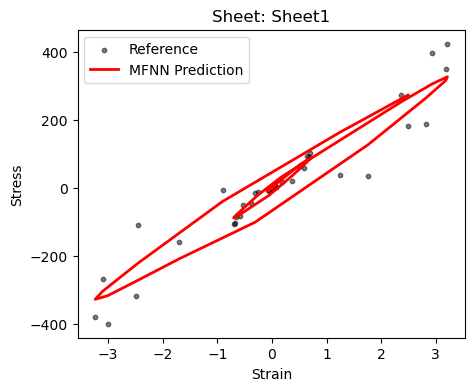

Processing Complete.


In [11]:
# %%
# 7. VISUALIZATION & EXPORT (CORRECTED)
print("\nGenerating Output Plots...")

def raw_extractor(sheet_idx, raw_data_dict):
    # Get the sheet name and dataframe
    sheet_name = list(raw_data_dict.keys())[sheet_idx]
    df = raw_data_dict[sheet_name].dropna()
    
    # --- ROBUST COLUMN EXTRACTION ---
    # Tries to find 'Strain', if not found, tries 'st', etc.
    
    # 1. Strain
    if 'Strain' in df.columns: st = df['Strain'].values
    else: st = df.iloc[:, 3].values # Fallback by index if names fail completely
        
    # 2. Strain Rate
    if 'StrainRate' in df.columns: sr = df['StrainRate'].values
    elif 'Shear rate' in df.columns: sr = df['Shear rate'].values
    else: sr = df.iloc[:, 4].values
        
    # 3. Angular Frequency
    if 'AngFreq' in df.columns: w = df['AngFreq'].values
    elif 'Angular frequency' in df.columns: w = df['Angular frequency'].values
    else: w = df.iloc[:, 2].values
        
    # 4. G0 (Amplitude)
    if 'G0' in df.columns: g0 = df['G0'].values
    elif 'Oscillation strain' in df.columns: g0 = df['Oscillation strain'].values
    else: g0 = df.iloc[:, 0].values
        
    # 5. Stress
    if 'Stress' in df.columns: s = df['Stress'].values
    else: s = df.iloc[:, 5].values
        
    # 6. Time
    if 'Time' in df.columns: t = df['Time'].values
    elif 'Step time' in df.columns: t = df['Step time'].values
    else: t = df.iloc[:, 1].values
    
    return t, g0, w, st, sr, s, sheet_name

# Reload raw data or fallback to HF processed
try:
    df_raw = pd.read_excel(url_hf_raw, sheet_name=None)
    print("Using RAW data file for plotting.")
except:
    print("Raw file not found. Using PROCESSED HF data for plotting.")
    df_raw = df_HF

now = datetime.now().strftime("%Y_%m_%d-%H_%M_%S")

with pd.ExcelWriter(f"Results_{now}.xlsx") as writer:
    # Iterate through all sheets
    for i in range(len(df_raw)):
        try:
            t_test, g0_test, w_test, st_test, sr_test, s_test, sn = raw_extractor(i, df_raw)
            
            # 1. Construct Input Matrix [Strain, Rate, Freq, G0]
            X_test = np.column_stack([st_test, sr_test, w_test, g0_test])
            X_test = tf.convert_to_tensor(X_test, dtype=DTYPE)
            
            # 2. Normalize 
            X_test_norm = X_test / norm_X
            
            # 3. Predict 
            y_LF_pred = model_LF(X_test_norm)
            X_MF_input = tf.concat([X_test_norm, y_LF_pred], axis=1)
            y_MF_pred_norm = model_HF_nl(X_MF_input) + model_HF_l(X_MF_input)
            
            # 4. Denormalize
            y_MF_pred = y_MF_pred_norm * norm_Y
            y_MF_pred = y_MF_pred.numpy().flatten()
            
            # 5. Plot
            plt.figure(figsize=(5, 4))
            plt.title(f"Sheet: {sn}")
            plt.scatter(st_test, s_test, label='Reference', color='black', s=10, alpha=0.5)
            plt.plot(st_test, y_MF_pred, label='MFNN Prediction', color='red', linewidth=2)
            plt.xlabel('Strain')
            plt.ylabel('Stress')
            plt.legend()
            plt.show()
            
            # 6. Save
            df_out = pd.DataFrame({
                'Time': t_test,
                'Strain': st_test,
                'Stress_Ref': s_test,
                'Stress_Pred': y_MF_pred
            })
            df_out.to_excel(writer, sheet_name=str(sn)[:30], index=False)
            
        except Exception as e:
            print(f"Skipping sheet {i} due to error: {e}")

print("Processing Complete.")